# Join parts into one model

In this tutorial we build a waveguide from three parts: an air section, a
50 mm dielectric slab ($\varepsilon_r = 2$) and a second air section. We solve
each part on its own, reduce each one, join the reduced models, and check the
slab's reflection against the closed-form solution and against the same model
solved in one piece.

Unlike a uniform guide, the slab reflects part of the wave, so $S_{11}$ is no
longer zero.

**Prerequisites:** [Cut a model into domains](../models/splitting_cad.ipynb)
and [Fill a waveguide with lossy material](../models/materials_and_losses.ipynb).

## 1. Build the model from three parts

### 1.1 Add the first air section

In [1]:
from cavsim3d.core.em_project import EMProject
from cavsim3d.geometry.primitives import RectangularWaveguide

proj = EMProject(name="combine_parts", base_dir="./simulations", overwrite=True)

proj.create_primitive("rwg", name="inlet", a=0.1, b=0.05, L=0.1, maxh=0.02)
proj.parts

✅ Creating new project 'combine_parts' at simulations\combine_parts


{'inlet': <cavsim3d.geometry.primitives.RectangularWaveguide at 0x258bc18ad50>}

### 1.2 Add the dielectric slab

The slab is a 50 mm waveguide section with a material, created on its own and
added under the name `slab`.

In [2]:
slab = RectangularWaveguide(a=0.1, b=0.05, L=0.05, maxh=0.02)
slab.set_materials({"*": {"eps_r": 2.0}})

proj.add("slab", slab)
list(proj.parts)

['inlet', 'slab']

Two parts now. With more than one part, the project chains them in the order
they were added.

### 1.3 Add the second air section

In [3]:
proj.create_primitive("rwg", name="outlet", a=0.1, b=0.05, L=0.1, maxh=0.02)
list(proj.parts)

['inlet', 'slab', 'outlet']

In [4]:
# proj.geo.show()                # the chained geometry; works any time, even before meshing
# proj.geo.show("inspect")       # each part in its own colour

### 1.4 Mesh the chain

Meshing prints the layout: the axis the parts are chained along, where each
part sits, and how the parts are meshed.

In [5]:
proj.generate_mesh(maxh=0.02)
print(f"{proj.mesh.ne} tetrahedra")

Main axis: Z (default). Parts follow the list order along +Z:
  1. inlet: z = [0, 0.1] m
  2. slab: z = [0.1, 0.15] m
  3. outlet: z = [0.15, 0.25] m
Mesh strategy: glued (one conformal mesh of all parts; all parts are geometry, each used once)

Assembly domain-material mapping:
  inlet: ['inlet/vacuum']
  slab: ['slab/vacuum']
  outlet: ['outlet/vacuum']
Port naming complete:
  Total ports: 4
  External ports: 2
  Interface ports: 2
618 tetrahedra


In [6]:
# proj.geo.show("mesh")          # the mesh, after proj.generate_mesh(...)

Three things to read in the output:

* `Main axis: Z (default)`: the parts follow each other along +z;
* the z-range of each part: `inlet` from 0 to 0.1 m, `slab` from 0.1 to
  0.15 m, `outlet` from 0.15 to 0.25 m;
* `Mesh strategy: glued`: the three parts share one mesh, with matching
  elements on the faces where they touch.

### 1.5 Look at the model

In [7]:
# proj.draw_material_cf("eps")

The slab stands out in the middle of the guide: its $\varepsilon_r$ is 2, the
air sections' is 1.

### 1.6 Check the ports

In [8]:
proj.fds.print_port_map()


Structure Topology
  Type: Compound structure
  Domains (3): ['inlet', 'slab', 'outlet']
  Ports (4): ['port1', 'port2', 'port3', 'port4']
  Mesh elements: 618
  External Ports (2): ['port1', 'port4']
  Internal Ports (2): ['port2', 'port3']

  Domain-Port Mapping:
    inlet: ['port1 (input)', 'port2 (internal)']
    slab: ['port2 (internal)', 'port3 (internal)']
    outlet: ['port3 (internal)', 'port4 (output)']
 idx  port      geometry    dims [mm]                 carries       role
   0  port1     rectangular area=5000.0 mm^2          TE/TM         external
   1  port2     rectangular area=5000.0 mm^2          TE/TM         internal (join)
   2  port3     rectangular area=5000.0 mm^2          TE/TM         internal (join)
   3  port4     rectangular area=5000.0 mm^2          TE/TM         external

nportmodes accepts:
  int   nportmodes=1
  list  nportmodes=[1, 1, 1, 1]   (one entry per port, this order)
  dict  nportmodes={'port1': 1, 'port2': 1, 'default': 1}

  2 internal (join)

Four ports: `port1` and `port4` at the two ends are external; `port2` and
`port3`, the faces between the parts, are internal.

## 2. Solve, reduce and join

### 2.1 Solve each part

We sweep from 0.5 to 4.5 GHz. For a model of several parts, `solve()` solves
each part on its own.

In [9]:
fom_res = proj.fds.solve(fmin=0.5, fmax=4.5, nsamples=41)

Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_10, kc=31.4159, sigma=+1
	port2 mode 0: TE_10, kc=31.4159, sigma=+1
	port3 mode 0: TE_10, kc=31.4159, sigma=+1
	port4 mode 0: TE_10, kc=31.4159, sigma=+1
Port eigenmodes complete: 4 total modes



FDS Solve: 0.5000 - 4.5000 GHz, 41 samples


Per-Domain Solve


    Completed: 2 ports, 41 frequencies in 24.48s (total iteration steps: 8314)


    Completed: 2 ports, 41 frequencies in 20.15s (total iteration steps: 7818)


    Completed: 2 ports, 41 frequencies in 28.15s (total iteration steps: 8585)


### 2.2 Reduce each part

In [10]:
roms = proj.fds.foms.reduce(tol=1e-6)

Model Order Reduction


Reduction complete: 16532 -> 77 DOFs (99.5% compression)


### 2.3 Join the reduced parts

In [11]:
concat = roms.concatenate()
res = concat.solve(fmin=0.5, fmax=4.5, nsamples=2000)


Concat Solve: 0.5 - 4.5 GHz, 2000 samples, system size 75


  Concat solve complete: 0.053s (2000 frequencies)


### 2.4 Look at the reflection

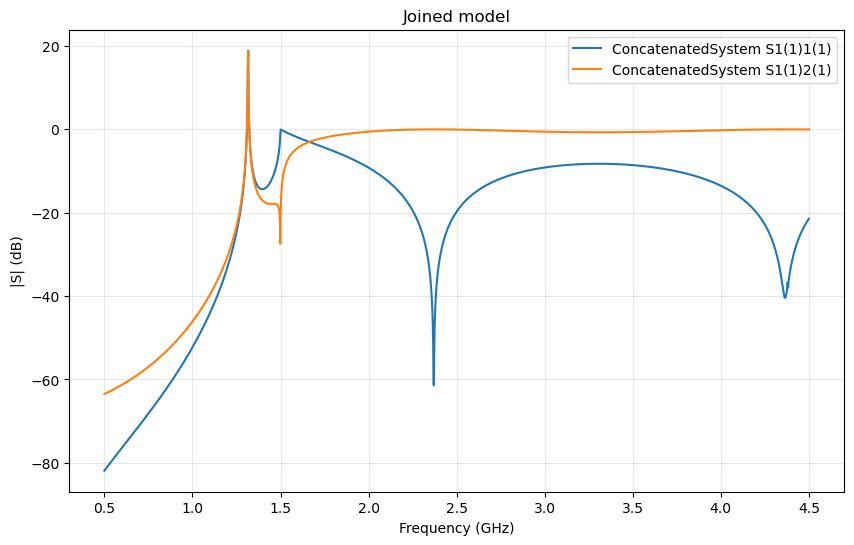

In [12]:
fig, ax = concat.plot_s(["1(1)1(1)", "1(1)2(1)"], title="Joined model")

$S_{11}$ is now a real reflection. Above the air's cutoff at 1.5 GHz it falls
from 0 dB to around −10 dB, with two deep dips, near 2.37 and 4.37 GHz: there
the slab is one and two half wavelengths long, and the reflections from its two
faces cancel.

Below 1.5 GHz the wave cannot travel in the air sections but can in the slab
(its cutoff is $1.5/\sqrt{2} \approx 1.06$ GHz). The slab traps it and
resonates: the sharp peak near 1.31 GHz.

## 3. Check against the closed-form solution

### 3.1 Compute the exact S-parameters

A slab in a matched waveguide is a textbook case. With
$k_{z1} = \sqrt{k_0^2 - k_c^2}$ in air, $k_{z2} = \sqrt{2 k_0^2 - k_c^2}$ in
the slab, the face reflection $\Gamma = (k_{z1} - k_{z2}) / (k_{z1} + k_{z2})$
and $P = e^{-2 j k_{z2} d}$:

$$S_{11} = \frac{\Gamma (1 - P)}{1 - \Gamma^2 P}\, e^{-2 j k_{z1} L_1},
  \qquad
  S_{21} = \frac{(1 - \Gamma^2)\, e^{-j k_{z2} d}}{1 - \Gamma^2 P}\,
           e^{-j k_{z1} (L_1 + L_3)}$$

where $d = 0.05$ m is the slab and $L_1 = L_3 = 0.1$ m the air sections.

In [13]:
import numpy as np

c0 = 299792458.0
kc = np.pi / 0.1
f = res["frequencies"]
k0 = 2 * np.pi * f / c0

kz1 = np.sqrt(k0**2 - kc**2 + 0j)
kz2 = np.sqrt(2.0 * k0**2 - kc**2 + 0j)
kz1 = np.where(kz1.imag > 0, -kz1, kz1)             # decaying branch below cutoff
kz2 = np.where(kz2.imag > 0, -kz2, kz2)

G = (kz1 - kz2) / (kz1 + kz2)
P = np.exp(-2j * kz2 * 0.05)
S11_exact = G * (1 - P) / (1 - G**2 * P) * np.exp(-2j * kz1 * 0.1)
S21_exact = (1 - G**2) * np.exp(-1j * kz2 * 0.05) / (1 - G**2 * P) * np.exp(-1j * kz1 * 0.2)

k = np.argmin(np.abs(f - 2.0e9))
print(f"at {f[k] / 1e9:.2f} GHz: exact |S11| = {abs(S11_exact[k]):.4f}, "
      f"joined model {abs(res['S'][k, 0, 0]):.4f}")

at 2.00 GHz: exact |S11| = 0.3463, joined model 0.3463


### 3.2 Compare the S-parameters

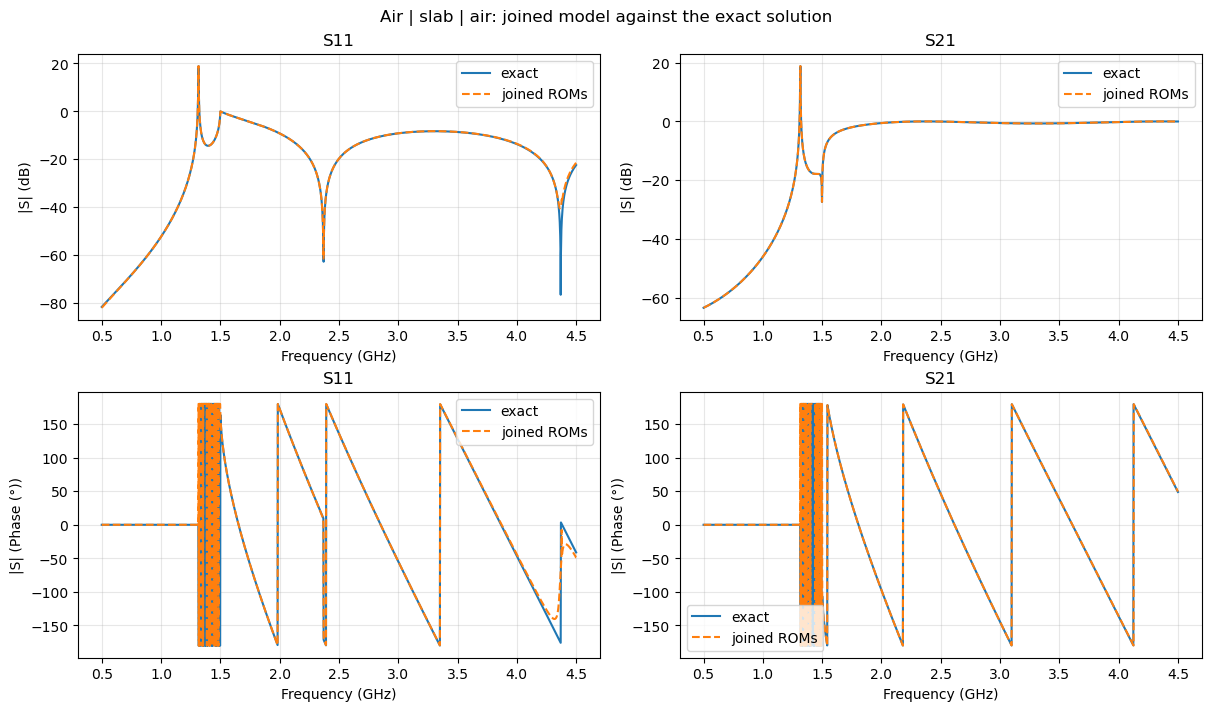

In [14]:
import matplotlib.pyplot as plt

fig, axs = plt.subplot_mosaic([["11 db", "21 db"], ["11 phase", "21 phase"]],
                              figsize=(12, 7), layout="constrained")
for ij, exact in (("11", S11_exact), ("21", S21_exact)):
    axs[f"{ij} db"].plot(f / 1e9, 20 * np.log10(np.abs(exact)), label="exact")
    axs[f"{ij} phase"].plot(f / 1e9, np.degrees(np.angle(exact)), label="exact")
    label = f"{ij[1]}(1){ij[0]}(1)"
    for kind in ("db", "phase"):
        concat.plot_s([label], plot_type=kind, ax=axs[f"{ij} {kind}"],
                      label="joined ROMs", ls="--", title=f"S{ij}")
fig.suptitle("Air | slab | air: joined model against the exact solution")
plt.show()

The dashed curves of the joined model lie on the exact ones, including the
two reflection dips and the trapped resonance at 1.31 GHz. At that resonance
the magnitudes exceed 0 dB: below the air's cutoff the ports' reference
impedance is reactive, and $|S|$ is no longer bounded by 1. The phase below
1.5 GHz jumps rapidly for the same reason.

### 3.3 Measure the difference

In [15]:
above = f > 1.6e9
err11 = np.abs(res["S"][:, 0, 0] - S11_exact)
err21 = np.abs(res["S"][:, 1, 0] - S21_exact)
print(f"above 1.6 GHz, median |S11 - exact| = {np.median(err11[above]):.1e}, "
      f"median |S21 - exact| = {np.median(err21[above]):.1e}")

above 1.6 GHz, median |S11 - exact| = 1.3e-03, median |S21 - exact| = 1.2e-03


## 4. Compare with the model solved in one piece

### 4.1 Solve the same parts in one piece

`per_domain=False` asks `solve()` to treat the whole mesh as one system
instead of one system per part. We use a second project, so that the
per-part results above stay as they are.

In [16]:
whole = EMProject(name="combine_parts_one_piece", base_dir="./simulations", overwrite=True)
whole.create_primitive("rwg", name="inlet", a=0.1, b=0.05, L=0.1, maxh=0.02)
slab2 = RectangularWaveguide(a=0.1, b=0.05, L=0.05, maxh=0.02)
slab2.set_materials({"*": {"eps_r": 2.0}})
whole.add("slab", slab2)
whole.create_primitive("rwg", name="outlet", a=0.1, b=0.05, L=0.1, maxh=0.02)
whole.generate_mesh(maxh=0.02)

whole_res = whole.fds.solve(fmin=0.5, fmax=4.5, nsamples=41, per_domain=False)
print("one-piece result:", whole_res["S"].shape)

✅ Creating new project 'combine_parts_one_piece' at simulations\combine_parts_one_piece


Main axis: Z (default). Parts follow the list order along +Z:
  1. inlet: z = [0, 0.1] m
  2. slab: z = [0.1, 0.15] m
  3. outlet: z = [0.15, 0.25] m
Mesh strategy: glued (one conformal mesh of all parts; all parts are geometry, each used once)

Assembly domain-material mapping:
  inlet: ['inlet/vacuum']
  slab: ['slab/vacuum']
  outlet: ['outlet/vacuum']
Port naming complete:
  Total ports: 4
  External ports: 2
  Interface ports: 2



Structure Topology
  Type: Compound structure
  Domains (3): ['inlet', 'slab', 'outlet']
  Ports (4): ['port1', 'port2', 'port3', 'port4']
  Mesh elements: 618
  External Ports (2): ['port1', 'port4']
  Internal Ports (2): ['port2', 'port3']

  Domain-Port Mapping:
    inlet: ['port1 (input)', 'port2 (internal)']
    slab: ['port2 (internal)', 'port3 (internal)']
    outlet: ['port3 (internal)', 'port4 (output)']



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_10, kc=31.4159, sigma=+1
	port2 mode 0: TE_10, kc=31.4159, sigma=+1
	port3 mode 0: TE_10, kc=31.4159, sigma=+1
	port4 mode 0: TE_10, kc=31.4159, sigma=+1
Port eigenmodes complete: 4 total modes



FDS Solve: 0.5000 - 4.5000 GHz, 41 samples


Global Coupled Solve


  
Coupled solve complete: 2 external ports in 79.87s (total iteration steps: 13682)


one-piece result: (41, 2, 2)


This sweep solves the whole mesh at once, with only the two end faces as ports.

### 4.2 Compare the S-parameters

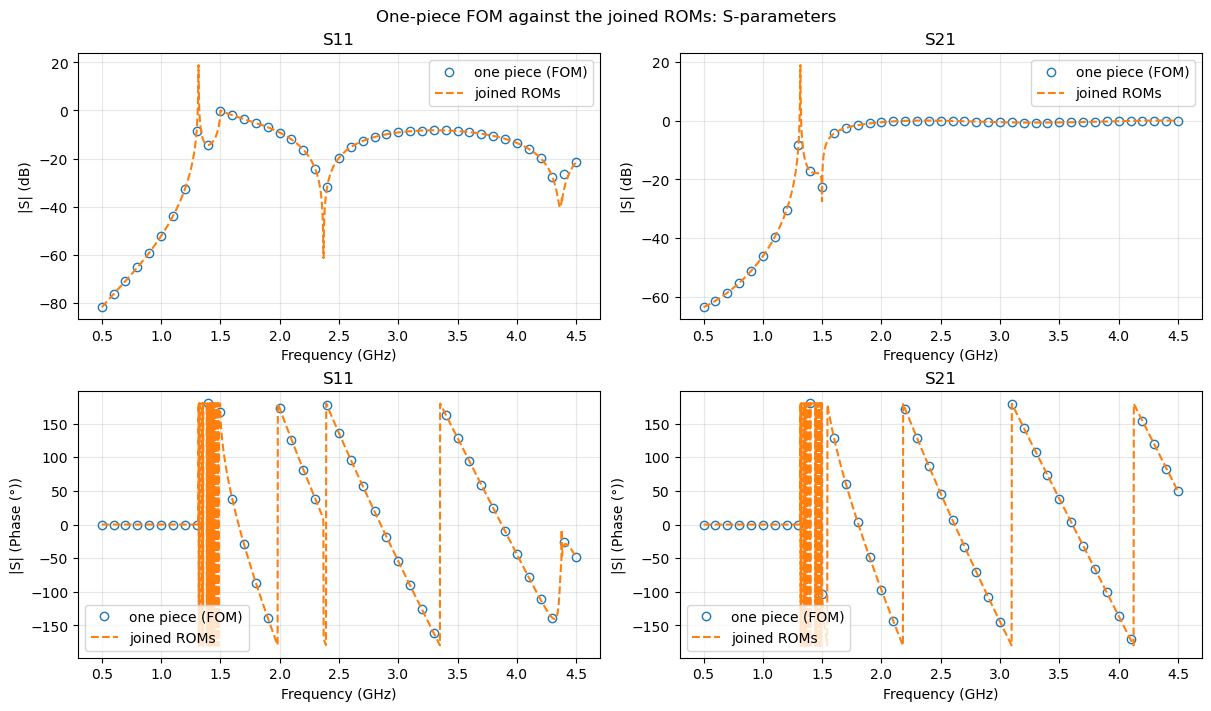

In [17]:
one_piece = whole.fds.fom

fig, axs = plt.subplot_mosaic([["11 db", "21 db"], ["11 phase", "21 phase"]],
                              figsize=(12, 7), layout="constrained")
for ij in ("11", "21"):
    label = f"{ij[1]}(1){ij[0]}(1)"
    for kind in ("db", "phase"):
        ax = axs[f"{ij} {kind}"]
        one_piece.plot_s([label], plot_type=kind, ax=ax, label="one piece (FOM)",
                         lw=0, marker="o", mfc="none")
        concat.plot_s([label], plot_type=kind, ax=ax, label="joined ROMs",
                      ls="--", title=f"S{ij}")
fig.suptitle("One-piece FOM against the joined ROMs: S-parameters")
plt.show()

### 4.3 Compare the Z-parameters

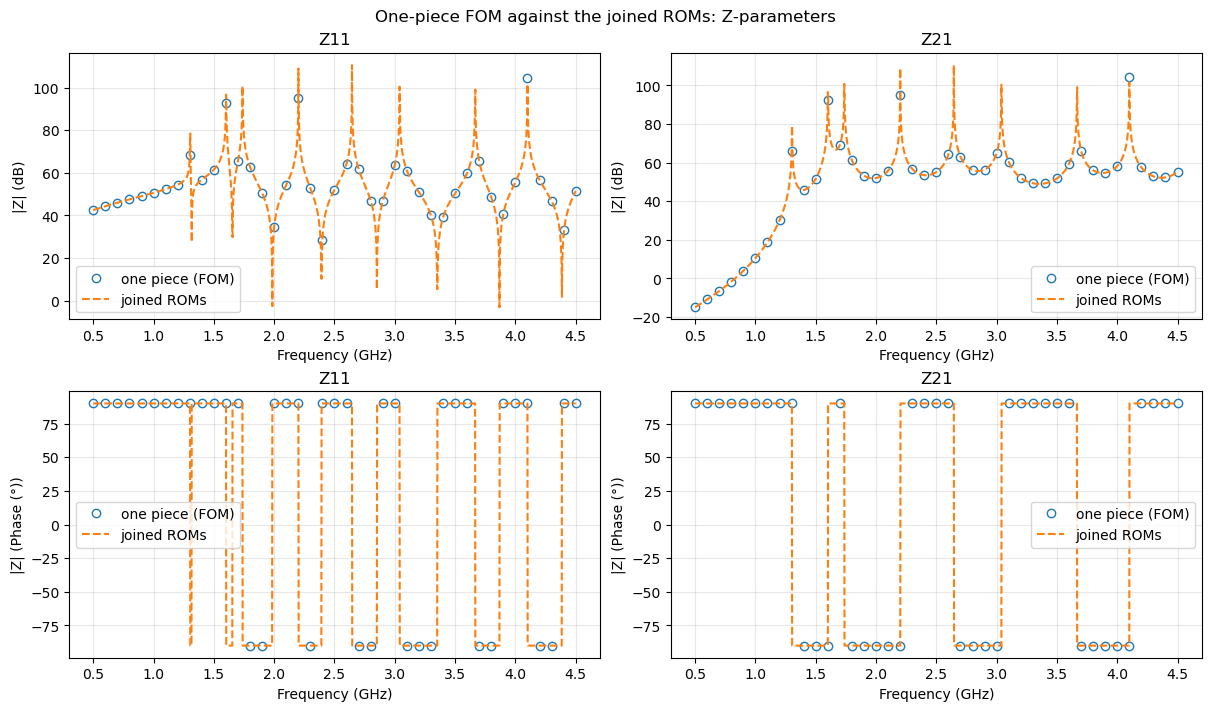

In [18]:
fig, axs = plt.subplot_mosaic([["11 db", "21 db"], ["11 phase", "21 phase"]],
                              figsize=(12, 7), layout="constrained")
for ij in ("11", "21"):
    label = f"{ij[1]}(1){ij[0]}(1)"
    for kind in ("db", "phase"):
        ax = axs[f"{ij} {kind}"]
        one_piece.plot_z([label], plot_type=kind, ax=ax, label="one piece (FOM)",
                         lw=0, marker="o", mfc="none")
        concat.plot_z([label], plot_type=kind, ax=ax, label="joined ROMs",
                      ls="--", title=f"Z{ij}")
fig.suptitle("One-piece FOM against the joined ROMs: Z-parameters")
plt.show()

The two routes agree across the band: solving the parts separately, reducing
them and joining them gives the same answer as solving the whole mesh.
The one-piece sweep, with a sample every 0.1 GHz, steps over the narrow trapped
resonance at 1.31 GHz that the joined model resolves.

### 4.4 Compare the sizes

In [19]:
print(f"full-order unknowns, all parts: {roms.mor.total_dofs}")
print(f"unknowns of the joined model:   {concat.coupled_dofs}")

full-order unknowns, all parts: 16532
unknowns of the joined model:   75


The joined model answers every frequency with fewer than a hundred unknowns
instead of many thousands.

## What we did

We chained three parts, one of them a dielectric slab, solved each part on its
own, reduced and joined them, and matched the joined model's reflection and
transmission to the closed-form solution and to the same model solved in one
piece.

**Next:** [Repeat a section](repeated_sections.ipynb) builds a chain of
identical parts, each solved only once.

**Background:** [How a model is solved in pieces](../../explanation/architecture.md)
compares the three ways of solving a model of several parts.